The size of the gascap is uncertain with the best estimate, based on geological information, giving the value of m = 0.4. What's the impact of m on N, show that with different values of m, how the estimated N varies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
Pb = 3330
Pi = 3330
P = np.array([3330,3150,3000,2850,2700,2550,2400]) #psi
Np = np.array([0, 3.295, 5.903,8.852,11.503,14.513,17.730]) #MMSTB
Rp  = np.array([0,1050,1060,1160,1235,1265,1300]) #scf/stb
Bo = np.array([1.2511,1.2353,1.2222,1.2122,1.2022,1.1922,1.1822]) #rb/STB
Rs = np.array([510,477,450,425,401,375,352]) #scf/stb
Bg = np.array([0.00087,0.00092,0.00096,0.00101,0.00107,0.00113,0.00120]) #rb/scf
     

In [3]:
df = pd.DataFrame({'P':P,'Np':Np,'Rp':Rp,'Bo':Bo,'Rs':Rs,'Bg':Bg})

In [4]:
df

,P,Np,Rp,Bo,Rs,Bg
0,3330,0.000,0,1.2511,510,0.00087
1,3150,3.295,1050,1.2353,477,0.00092
2,3000,5.903,1060,1.2222,450,0.00096
3,2850,8.852,1160,1.2122,425,0.00101
4,2700,11.503,1235,1.2022,401,0.00107
5,2550,14.513,1265,1.1922,375,0.00113
6,2400,17.730,1300,1.1822,352,0.00120


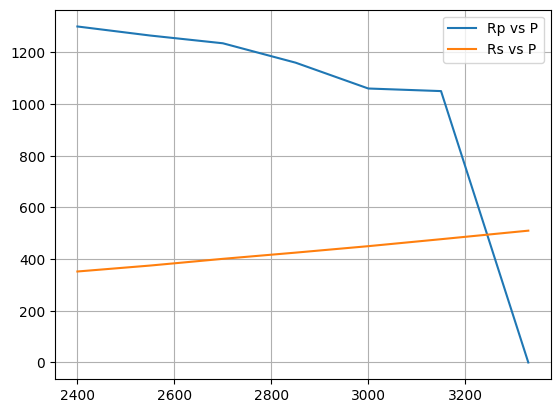

In [6]:
plt.plot(P,Rp,label='Rp vs P')
plt.plot(P,Rs,label='Rs vs P')
plt.legend()
plt.grid()

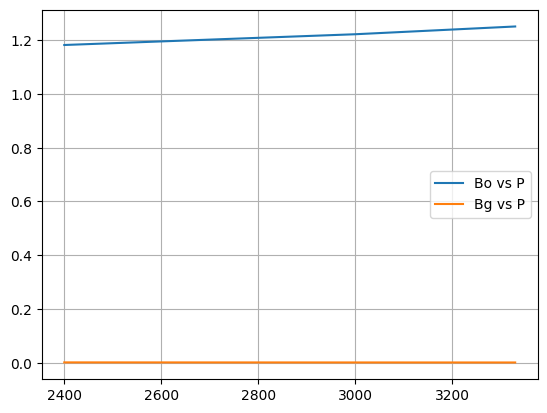

In [7]:
plt.plot(P,Bo,label='Bo vs P')
plt.plot(P,Bg,label='Bg vs P')
plt.legend()
plt.grid()

In [8]:
df

,P,Np,Rp,Bo,Rs,Bg
0,3330,0.000,0,1.2511,510,0.00087
1,3150,3.295,1050,1.2353,477,0.00092
2,3000,5.903,1060,1.2222,450,0.00096
3,2850,8.852,1160,1.2122,425,0.00101
4,2700,11.503,1235,1.2022,401,0.00107
5,2550,14.513,1265,1.1922,375,0.00113
6,2400,17.730,1300,1.1822,352,0.00120


**Method-1**

In [9]:
#Oil Expansion factor
Eo = Bo - Bo[0] + (Rs[0] - Rs)*Bg

#Gas Expansion Factor
Eg = Bo[0]*((Bg/Bg[0])-1)

#Underground Withdrawal
F = Np*(Bo + (Rp - Rs)*Bg)

In [11]:
df_MBE = pd.DataFrame({'P':P,'F':F,'Eo':Eo,'Eg':Eg})
df_MBE

,P,F,Eo,Eg
0,3330,0.000000,0.00000,0.000000
1,3150,5.807306,0.01456,0.071902
2,3000,10.671443,0.02870,0.129424
3,2850,17.301677,0.04695,0.201326
4,2700,24.093954,0.06773,0.287609
5,2550,31.898123,0.09365,0.373892
6,2400,41.130054,0.12070,0.474555


In [12]:
# now let's assume 3 values of m
m1 = 0.4 
m2 = 0.5
m3 = 0.6

E1 = Eo + m1*Eg
E2 = Eo + m2*Eg
E3 = Eo + m3*Eg
     
df_MBE['E1'] = E1
df_MBE['E2'] = E2
df_MBE['E3'] = E3

In [13]:
df_MBE

,P,F,Eo,Eg,E1,E2,E3
0,3330,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1,3150,5.807306,0.01456,0.071902,0.043321,0.050511,0.057701
2,3000,10.671443,0.02870,0.129424,0.080470,0.093412,0.106354
3,2850,17.301677,0.04695,0.201326,0.127481,0.147613,0.167746
4,2700,24.093954,0.06773,0.287609,0.182774,0.211535,0.240296
5,2550,31.898123,0.09365,0.373892,0.243207,0.280596,0.317985
6,2400,41.130054,0.12070,0.474555,0.310522,0.357978,0.405433


Text(0.5, 1.0, 'Slope gives us The N (Oil in Place')

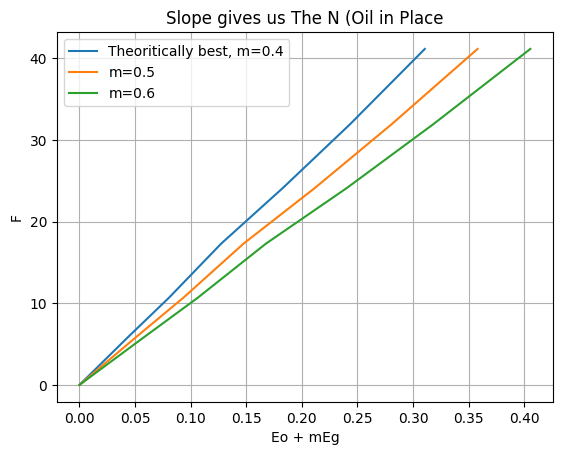

In [16]:
plt.plot(df_MBE['E1'],F,label='Theoritically best, m=0.4')
plt.plot(df_MBE['E2'],F,label='m=0.5')
plt.plot(df_MBE['E3'],F,label='m=0.6')

plt.grid()
plt.legend(loc='best')

plt.xlabel('Eo + mEg')
plt.ylabel('F')
plt.title('Slope gives us The N (Oil in Place')

In [18]:
slope1, intercept = np.polyfit(df_MBE['E1'],F, 1)
slope2, intercept2 = np.polyfit(df_MBE['E2'],F, 1)
slope3, intercept3 = np.polyfit(df_MBE['E3'],F, 1)

print(f'1. The Estimate of N (Oil in place) with m = 0.4 is {slope1} MMSTB')
print(f'2. The Estimate of N (Oil in place) with m = 0.5 is {slope2} MMSTB')
print(f'2. The Estimate of N (Oil in place) with m = 0.6 is {slope3} MMSTB')

1. The Estimate of N (Oil in place) with m = 0.4 is 131.77712071961056 MMSTB
2. The Estimate of N (Oil in place) with m = 0.5 is 114.37046619758794 MMSTB
2. The Estimate of N (Oil in place) with m = 0.6 is 101.02489219651801 MMSTB


**Method-2**

In [34]:
df_MBE['F/Eo'] = df_MBE['F']/df_MBE['Eo']
df_MBE['Eg/Eo'] = df_MBE['Eg']/df_MBE['Eo']
df_MBE

,P,F,Eo,Eg,E1,E2,E3,F/Eo,Eg/Eo
0,3330,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,3150,5.807306,0.01456,0.071902,0.043321,0.050511,0.057701,398.853413,4.938345
2,3000,10.671443,0.02870,0.129424,0.080470,0.093412,0.106354,371.827296,4.509552
3,2850,17.301677,0.04695,0.201326,0.127481,0.147613,0.167746,368.512814,4.288103
4,2700,24.093954,0.06773,0.287609,0.182774,0.211535,0.240296,355.735328,4.246408
5,2550,31.898123,0.09365,0.373892,0.243207,0.280596,0.317985,340.609959,3.992439
6,2400,41.130054,0.12070,0.474555,0.310522,0.357978,0.405433,340.762668,3.931692


In [38]:
mn, n = np.polyfit(df_MBE['Eg/Eo'].iloc[1:],df_MBE['F/Eo'].iloc[1:], 1)

Text(0.5, 1.0, 'A history match/verification of results')

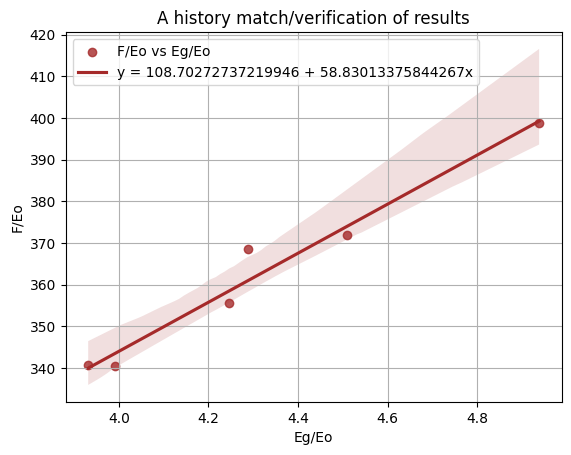

In [41]:
# plt.plot(df_MBE['Eg/Eo'], df_MBE['F/Eo'])

sns.regplot(x='Eg/Eo',y='F/Eo',data=df_MBE,label = 'F/Eo vs Eg/Eo',line_kws={'label':f'y = {n} + {mn}x'},color='brown')
plt.grid()
plt.legend(loc='best')
plt.title('A history match/verification of results')

In [42]:
print(f'1.Based on the practical production Data, The correct value of N(OIP) is: {n}')
print(f'2.Based on the practical production Data, The correct value of m is: {mn/n}')

1.Based on the practical production Data, The correct value of N(OIP) is: 108.70272737219946
2.Based on the practical production Data, The correct value of m is: 0.5412020027520338
